# Трёхмерная реконструкция с помощью модели NeRF

**План задания:** реализуем простейшую модель для реконструкции трёхмерных сцен. Для этого напишем архитектуру модели, а также алгоритм отрисовки кадров.

**Цель задания:** познакомиться с основными принципами работы современных моделей многовидовой реконструкции.

**Формат:** дозаполнить поля с подписью "TODO".

## Импортируем библиотеки

In [1]:
import os
import gc
import json
from tqdm import tqdm
from IPython.display import clear_output

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.jit as jit
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

assert device == 'cuda', "В этом занятии нам понадобится GPU!"

## Подготовка данных

Скачаем и разархивируем данные. В качестве обучаемой выборки возьмем синтетический датасет с моделью трактора из Lego.

In [3]:
if not os.path.exists('nerf_synthetic'):
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/nerf_example_data.zip
    !unzip nerf_example_data.zip
    clear_output()

Вместе с картинками данные содержат параметры камеры, которые мы считаем ниже.

In [4]:
def read_json(file_dir):
    with open(file_dir) as fp:
        data = json.load(fp)
    return data

def read_focal(image_width, metadata) -> float:
    camera_angle_x = float(metadata["camera_angle_x"])
    return 0.5 * image_width / np.tan(0.5 * camera_angle_x)

def read_data(base_dir, metadata, scale=1, count=None):
    imgs, poses = [], []

    if count is None:
        count = len(metadata["frames"])

    for frame in tqdm(metadata["frames"][:count], desc=f"Loading Data"):
        img = os.path.join(base_dir, f"{frame['file_path'][2:]}.png")
        img = Image.open(img)

        if scale < 1.:
            w, h = img.width, img.height
            w = int(np.floor(scale * w))
            h = int(np.floor(scale * h))
            img = img.resize((w, h), Image.LANCZOS)

        img = transforms.ToTensor()(img).permute(1, 2, 0)
        img = img[:, :, :3] * img[:, :, -1:]
        imgs.append(img)

        pose = frame["transform_matrix"]
        pose = torch.FloatTensor(pose)
        poses.append(pose)

    imgs = torch.stack(imgs, dim=0)
    poses = torch.stack(poses, dim=0)

    return imgs, poses

In [5]:
metadata_train = read_json("./nerf_synthetic/lego/transforms_train.json")
metadata_val = read_json("./nerf_synthetic/lego/transforms_val.json")
metadata_test = read_json("./nerf_synthetic/lego/transforms_test.json")

len(metadata_train["frames"]), len(metadata_val["frames"]), len(metadata_test["frames"])

(100, 100, 200)

### Данные для обучения

В модели NeRF для того, чтобы получить итоговый цвет, мы пускаем лучи из координат камеры по напралению к объекту через каждый пиксель изображения. В каждой точке луча $r(t) = o + t \cdot d$ модель будет предсказывать цвет и плотность объекта, что после будет агрегироваться в общий цвет.

In [6]:
def get_ray_direction(H, W, focal):
    """
    Get ray directions for all pixels in camera coordinate.
    Inputs:
        H, W, focal: image height, width and focal length
    Outputs:
        ray directions: (H, W, 3), the direction of the rays in camera coordinate
    """
    i, j = torch.meshgrid(torch.linspace(0, W - 1, W),
                          torch.linspace(0, H - 1, H))
    i, j = i.t(), j.t()
    return torch.stack(
        [
            (i - 0.5 * W) / focal,
            - (j - .5 * H) / focal,
            - torch.ones_like(i)
        ], -1)

@jit.script
def get_rays_with_dir(directions, c2w):
    """
    Get ray origin and normalized directions in world coordinate for all pixels in one image.
    Inputs:
        directions: (H, W, 3) precomputed ray directions in camera coordinate
        c2w: (4, 4) transformation matrix from camera coordinate to world coordinate
    Outputs:
        rays_o: (H, W, 3), the origin of the rays in world coordinate
        rays_d: (H, W, 3), the normalized direction of the rays in world coordinate
    """
    # Rotate ray directions from camera coordinate to the world coordinate
    rays_d = directions @ c2w[:3, :3].T # (H, W, 3)
    rays_d = rays_d / torch.norm(rays_d, dim=-1, keepdim=True)

    # The origin of all rays is the camera origin in world coordinate
    rays_o = c2w[:3, 3].expand(rays_d.shape) # (H, W, 3)
    return rays_o, rays_d

def build_rays(H, W, focal, poses):
    """
    Generate dataset rays (origin and direction)
    Inputs:
        dataset (BlenderDataset): dataset context
        H (int): frame height
        W (int): frame width
        focal (float): camera focal length
        poses (Tensor): camera to world matrices (N, 4, 4)
    Outputs:
        ros (Tensor): ray origins (N, H, W, 3)
        rds (Tensor): ray directions (N, H, W, 3)
    """
    N = poses.size(0)

    prd = get_ray_direction(H, W, focal)
    ros = torch.zeros((N, H, W, 3), dtype=torch.float32)
    rds = torch.zeros((N, H, W, 3), dtype=torch.float32)

    c2ws = tqdm(poses, desc=f"Building Rays")
    for i, c2w in enumerate(c2ws):
        ros[i], rds[i] = get_rays_with_dir(prd, c2w)

    return ros, rds

In [7]:
class NeRFDataset(Dataset):
    def __init__(self, metadata, scale=1, data_path="./nerf_synthetic/lego/", device='cpu', train=False):

        self.metadata = metadata

        self.images, self.poses = read_data(data_path, self.metadata , scale=scale)
        self.images = self.images.to(device)
        self.poses = self.poses.to(device)

        H, W = self.images.shape[1:3]
        self.focal = read_focal(W, self.metadata)

        ro, rd = build_rays(
            H, W,
            self.focal,
            self.poses,
        )

        if train:
            self.ro = ro.view(-1, 3)
            self.rd = rd.view(-1, 3)
            self.images = self.images.view(-1, 3)
        else:
            self.ro = ro
            self.rd = rd

        assert self.images.size() == self.ro.size()
        assert self.images.size() == self.rd.size()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return {
            'image': self.images[idx],
            'ro': self.ro[idx],
            'rd': self.rd[idx]
        }

In [8]:
dataset_train = NeRFDataset(metadata_train, scale=0.125, train=True)
dataset_val = NeRFDataset(metadata_val, scale=0.125)

Loading Data: 100%|██████████| 100/100 [00:02<00:00, 35.68it/s]
/root/deep_vision_and_graphics/homework05/.venv/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Building Rays: 100%|██████████| 100/100 [00:00<00:00, 2805.29it/s]


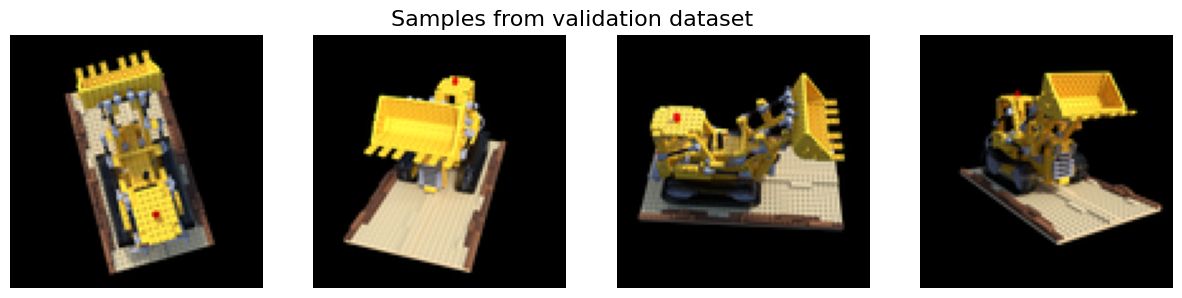

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axs[i].imshow(dataset_val.images[i])
    axs[i].axis('off')
fig.suptitle("Samples from validation dataset", y=0.8, fontsize=16)
plt.show()

## Архитектура модели (0.2 + 0.3 балла)

[NeRF](https://www.matthewtancik.com/nerf) представляет сцену с помощью полносвязной нейронной сети.

На вход поступает точка в пространстве $x$ и направление луча $d$.
Возвращает модель плотность $\sigma$ и цвет $C$.
Плотность $\sigma$ зависит от поступивших на вход координат точки, а цвет зависит как от координат, так и от направления движения луча. Для этого архитектура разбивается на несколько блоков:
$$
\begin{align}
h_1(x) &= \text{block}_1(x) \\
h_2(x), \sigma(x) &= \text{block}_2(x, h_1) \\
c(x, d) &= \text{block}_3(h_2, d)
\end{align},
$$
где каждый блок представляет из себя полносвязную нейронную сеть.
Каждый блок мог бы принимать на вход координаты в явном виде, однако более успешным оказывается подход с использованием позиционного кодирования входов сети.
Опишем его подробнее

Интуитивно, модель трёхмерной сцены должна допускать резкие изменения цвета и плотности в зависимости от $x$. Однако, [оказывается](https://arxiv.org/abs/2006.10739), что полносязная сеть требует долгого обучения для того чтобы добиться этого эффекта. В качестве обходного решения, в модели NeRF было предложено использовать позиционное кодирование входа:
$$
\gamma_L(x) = [x, \cos(2^0 \pi x), \sin(2^0 \pi x), \dots, \cos(2^{L - 1} \pi x), \sin(2^{L - 1} \pi x)].
$$
Выше приведена формула для скалярного $x$, а для векторного входа $x$ кодирование применяется к каждой координате по отдельности.

В итоге архитектура имеет следующий вид:
<img src="nerf_architecture.png" width="750">

Ниже вам надо реализовать функцию для позиционного кодирования и прямого прохода в классе для модели NeRF.

In [10]:
def positional_encoding(x, L, include_input=True):
    freq_bands = 2.0 ** torch.linspace(0, L-1, steps=L, device=x.device)
    scaled_x = x.unsqueeze(-1) * freq_bands
    sin_x = torch.sin(scaled_x)
    cos_x = torch.cos(scaled_x)
    enc = torch.cat([sin_x, cos_x], dim=-1).flatten(-2)
    if include_input:
        enc = torch.cat([x, enc], dim=-1)
    return enc


In [21]:
class NeRF(nn.Module):
    def __init__(self, hidden_dim=256, num_freq_x=10, num_freq_d=4, include_input=True):
        super(NeRF, self).__init__()

        self.num_freq_x = num_freq_x
        self.num_freq_d = num_freq_d
        self.include_input = include_input
        input_dim1 = (num_freq_x * 6 + 3) if self.include_input else (num_freq_x * 6)
        input_dim2 = (num_freq_d * 6 + 3) if self.include_input else (num_freq_d * 6) # direction vector is an unit vector

        self.block1 =  nn.Sequential(
            nn.Linear(input_dim1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(
            nn.Linear(input_dim1 + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim + 1), # add one number for density
        )
        self.block3 = nn.Sequential(
            nn.Linear(input_dim2 + hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3),
            nn.Sigmoid()
        )

    def forward(self, points, directions):
        # points, directions: [batch_size, 3]
        pos_points = positional_encoding(points, self.num_freq_x, self.include_input)
        h1 = self.block1(pos_points)
        # print(pos_points.shape, h1.shape)
        res_block2 = self.block2(torch.cat([pos_points, h1], dim=-1))
        h2 = res_block2[:, :-1]
        sigma = res_block2[:, -1]
        pos_directions = positional_encoding(directions, self.num_freq_d, self.include_input)
        c = self.block3(torch.cat([h2, pos_directions], dim=-1))
        return c, sigma

In [22]:
temp_model = NeRF()

temp_origins = torch.rand(10, 3)
temp_directions = torch.rand(10, 3)

c, sigma = temp_model(temp_origins, temp_directions)

assert c.shape == (10, 3), f"Output 'c' should have shape (10, 3), but got {c.shape}"
assert sigma.shape == (10,), f"Output 'sigma' should have shape (10,), but got {sigma.shape}"

### Отрисовка лучей (0.5 балла)

После вычисления плотности и цвета вдоль луча мы вычисляет цвет пикселя на изображении, аггрегируя цвет и плотность с помощью алгоритма $\alpha$-compositing.

Для $N$ точек $\{x_i\}_{i=1^N}$ луча $r$ введем обозначения $\sigma_i = \sigma(x_i)$ и $c_i = c(x_i, d)$, где $d$ обозначает направление луча.
Итоговый цвет $C(r)$ может быть вычислен по формуле (3) из оригинальной [статьи](https://arxiv.org/abs/2003.08934)
$$
C(r) = \sum_{i=1}^N \alpha_i \left( \prod_{j < i} (1 - \alpha_j) \right) c_i
$$
для непрозрачности $\alpha_i = 1 - \exp(-\sigma_i \delta_i)$ и ширины разбиения луча $\delta_i$ (можно считать $\delta_i = \tfrac{1}{N}$).

Формула перевзвешивает величины $c_i$, отдавая приоритет непрозрачным точкам встреченным для ранних индексов $i$.
Физическая интерпретация алгоритма описана в [этой](https://courses.cs.duke.edu/spring03/cps296.8/papers/max95opticalModelsForDirectVolumeRendering.pdf) статье.
Вес $w_i = \alpha_i \prod_{j < i} (1 - \alpha_i)$ соответствует вероятности события, при котором выпущенная с вероятностью $\alpha_i$ из точки $i$ частица света пройдет через точки $j < i$ с вероятностью прохождения $(1 - \alpha_j)$ и долетит до камеры.
Цвет $C(r)$, в свою очередь, соответствует среднему цвету пришедших частиц.

Ниже вам надо реализовать вычисление цвета пикселя по описанному выше алгоритму.

In [23]:
def get_ray_samples(ray_origins, hn, hf, nb_bins, device):
    t = torch.linspace(hn, hf, nb_bins, device=device).expand(ray_origins.shape[0], nb_bins)

    mid = (t[:, :-1] + t[:, 1:]) / 2.
    lower = torch.cat((t[:, :1], mid), -1)
    upper = torch.cat((mid, t[:, -1:]), -1)
    u = torch.rand(t.shape, device=device)

    t = lower + (upper - lower) * u  # [batch_size, nb_bins]
    delta = torch.cat((t[:, 1:] - t[:, :-1], torch.tensor([1e10], device=device).expand(ray_origins.shape[0], 1)), -1)
    return t, delta

def render_rays(nerf_model, ray_origins, ray_directions, hn=0, hf=0.5, nb_bins=192):

    device = ray_origins.device

    t, delta = get_ray_samples(ray_origins, hn, hf, nb_bins, device)

    # Compute the 3D points along each ray
    x = ray_origins.unsqueeze(1) + t.unsqueeze(2) * ray_directions.unsqueeze(1)   # [batch_size, nb_bins, 3]
    ray_directions = ray_directions.expand(nb_bins, ray_directions.shape[0], 3).transpose(0, 1)
    
    colors, sigma = nerf_model(x.reshape(-1, 3), ray_directions.reshape(-1, 3))
    alpha = torch.ones_like(sigma) - torch.exp(-sigma.mean())
    C = torch.sum(alpha * (1-alpha) * colors)
    return C

## Обучение

Давайте обучим модель, используя реализованные выше компоненты.

In [ ]:
def psnr(img_gd, img_gen):
    mse = ((img_gd - img_gen) ** 2).mean()
    mse = torch.clamp(mse, min=1e-10)
    return -10.0 * torch.log10(mse)

In [ ]:
def train(model, optimizer, scheduler, train_loader, val_img, device='cuda', hn=0, hf=1, nb_epochs=10, nb_bins=192, chunk_size=1024*6):

    psnr_values_val = []
    psnr_values_train = []

    for epoch in tqdm(range(nb_epochs), desc="Epochs"):
        psnr_train_epoch = []

        for batch in tqdm(train_loader, total=len(train_loader), leave=False, desc="Train batch"):
            model.train()
            ro = batch['ro'].to(device)
            rd = batch['rd'].to(device)
            color_gd = batch['image'].to(device)

            color_gen = render_rays(model, ro, rd, hn=hn, hf=hf, nb_bins=nb_bins)
            loss = ((color_gd - color_gen) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            psnr_train_epoch.append(psnr(color_gd, color_gen).item())


        psnr_values_train.append(np.mean(psnr_train_epoch))

        scheduler.step()

        with torch.no_grad():
            model.eval()
            ray_origins_val = val_img['ro'].view(-1, 3)
            ray_directions_val = val_img['rd'].view(-1, 3)
            image_gd_val = val_img['image'].view(-1, 3)
            rendered_chunks_val = []

            for i in tqdm(range(0, ray_origins_val.shape[0], chunk_size), leave=False, desc="Validation"):
                ro_chunk_val = ray_origins_val[i:i+chunk_size].to(device)
                rd_chunk_val = ray_directions_val[i:i+chunk_size].to(device)

                rgb_map_chunk_val = render_rays(model, ro_chunk_val, rd_chunk_val, hn=hn, hf=hf, nb_bins=nb_bins)
                rendered_chunks_val.append(rgb_map_chunk_val.cpu().detach())

            image_gen_val = torch.cat(rendered_chunks_val, dim=0)
            val_psnr = psnr(image_gd_val.cpu().detach(), image_gen_val)
            psnr_values_val.append(val_psnr)

            # clear_output(wait=True)
            plt.figure(figsize=(12, 8))
            plt.subplot(2, 2, 1)
            plt.plot(range(len(psnr_values_train)), psnr_values_train)
            plt.title(f"Train PSNR")

            plt.subplot(2, 2, 2)
            plt.plot(range(len(psnr_values_val)), psnr_values_val)
            plt.title("Val PSNR")

            plt.subplot(2, 2, 3)
            plt.imshow(image_gd_val.view(*val_img['image'].shape).cpu().detach().numpy())
            plt.axis("off")
            plt.title("Ground Truth Image (Val)")

            plt.subplot(2, 2, 4)
            plt.imshow(image_gen_val.view(*val_img['image'].shape).cpu().detach().numpy())
            plt.axis("off")
            plt.title("Generated Image (Val)")

            plt.suptitle(f"Results of epoch {epoch+1}")
            plt.show()

    return psnr_values_train, psnr_values_val

In [ ]:
model = NeRF(hidden_dim=256).to(device)
model_optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.MultiStepLR(model_optimizer, milestones=[2, 4, 8], gamma=0.5)

train_loader = DataLoader(dataset_train, batch_size=4000, shuffle=True)
val_img = dataset_val[5]

train(model, model_optimizer, scheduler, train_loader, val_img, nb_epochs=15, device=device, hn=2, hf=6)

Удалось ли сгенерировать правдоподобные реконструкции модели с помощью выученной сети?